In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, torch
import numpy as np
import matplotlib.pyplot as plt
from icecream import ic
from trianglechain import TriangleChain

from sbi.diagnostics.lc2st import LC2ST

from msfm.utils import files
from msi.utils import preprocessing, plotting
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow


2026-01-26 07:55:38.614061: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")

# # clustering: classic-frost-1096 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/fp2vxm07/overview)
# model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default"
# n_steps = 240_000
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# v14 combined
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
model_dir = "/global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default"
n_steps = 400_000
label = f"{n_steps}_steps_likelihood_sigmoid_test_v3"

_, s_grid, theta_grid, file_dict = preprocessing.get_reshaped_network_preds(
    model_dir,
    n_steps=n_steps,
    with_fidu=False,
)

mock = "Buzzard_0"
# mock = "Buzzard_3"
s_obs = file_dict[f"mocks/pred/{mock}"]

samples_file = os.path.join(model_dir, label, "likelihood_flow/mcmc_samples.h5")
# chain_file = os.path.join(model_dir, label, "likelihood_flow/


26-01-26 07:56:26 input_output INF   Loading predictions from /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/preds_400000.h5 
26-01-26 07:56:26 input_output INF   Array shapes: 
26-01-26 07:56:26 input_output INF   fiducial/vali/pred = (40000, 20) 
26-01-26 07:56:26 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-26 07:56:26 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-26 07:56:26 input_output INF   grid/pred          = (2500, 80, 20) 
26-01-26 07:56:26 input_output INF   grid/cosmo         = (2500, 80, 10) 
26-01-26 07:56:26 input_output INF   grid/i_example     = (2500, 80) 
26-01-26 07:56:26 input_output INF   grid/i_noise       = (2500, 80) 
26-01-26 07:56:26 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-26 07:56:26 preprocessin INF   Shapes after concatenation and selection: 
26-01-26 07:56:26 preprocessin INF   grid_preds  = (200000, 20) 
26-01-26 07:56:26 preproce

In [4]:
# fresh and simple flow, but for this we don't have posterior samples

# flow = LikelihoodFlow(
#     params, 
#     conf, 
#     feature_dim=preds.shape[-1],
#     out_dir=model_dir,
#     label=label,
#     load_existing=True,
# )

# flow.fit(
#     x=s_grid,
#     theta=theta_grid,
#     batch_size=10_000,
#     scheduler_type="cosine",
#     save_model=True,
# )


In [5]:
x_dim = s_grid.shape[-1]
theta_dim = theta_grid.shape[-1]
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 16,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

flow = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=model_dir,
    label=label,
    load_existing=True,
)


26-01-26 07:56:35 likelihood_b INF   Set up the model directory /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test_v3/likelihood_flow 
26-01-26 07:56:35 likelihood_f WAR   Assuming that the feature/summary dimension is equal to the context/parameter dimension 
26-01-26 07:56:35 likelihood_f INF   Initialized the normalizing flow 
26-01-26 07:56:35 likelihood_f INF   Running on device cuda with default float torch.float32 
26-01-26 07:56:35 likelihood_f INF   Loaded the model from /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test_v3/likelihood_flow/likelihood_flow.pt 


/global/u2/a/athomsen/multiprobe-simulation-inference/msi/flow_conductor/likelihood_flow.py:495: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.loa

In [6]:
with h5py.File(samples_file, "r") as f:
    for key in f.keys():
        print(f"{key}.shape = {f[key].shape}")


log_prob_sample.shape = (10000, 1000)
log_prob_true.shape = (1000,)
theta_sample.shape = (10000, 1000, 10)
theta_true.shape = (1000, 10)
x_true.shape = (1000, 20)


# SBI package
Following https://sbi.readthedocs.io/en/latest/advanced_tutorials/13_diagnostics_lc2st.html#set-up-ell-c2st

In [7]:
# use the same variable names as in the reference notebook
xs_star = s_obs
post_samples_star = flow.sample_posterior(xs_star)

i_rand = np.random.choice(np.arange(post_samples_star.shape[0]), 10_000)
post_samples_star = post_samples_star[i_rand]

ic(xs_star.shape)
ic(post_samples_star.shape)

xs_star = torch.from_numpy(xs_star)
post_samples_star = torch.from_numpy(post_samples_star)

26-01-26 07:56:43 likelihood_f INF   Sampling the posterior from a single observation 
26-01-26 07:56:43      mcmc.py INF   Initial values in prior: 49.6% 
26-01-26 07:56:43      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:25<00:00, 38.61it/s]

26-01-26 07:57:10      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:25<00:00, 39.18it/s]

26-01-26 07:57:35      mcmc.py INF   MAP parameters: {'Om': np.float64(0.263), 's8': np.float64(0.84), 'w0': np.float64(-1.075), 'Aia': np.float64(0.266), 'n_Aia': np.float64(2.17), 'bta': np.float64(1.458), 'bg1': np.float64(1.35), 'bg2': np.float64(1.545), 'bg3': np.float64(1.628), 'bg4': np.float64(1.727)} 


26-01-26 07:57:35      mcmc.py INF   Saved the MCMC chain to /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test_v3/likelihood_flow/chain.npy 


ic| xs_star.shape: (20,)
ic| post_samples_star.shape: (10000, 10)


In [8]:
with h5py.File(samples_file, "r") as f:
    x_cal = f["x_true"][:]
    theta_cal = f["theta_true"][:]
    post_samples_cal = f["theta_sample"][0,:,:]

ic(x_cal.shape)
ic(theta_cal.shape)
ic(post_samples_cal.shape);

x_cal = torch.from_numpy(x_cal)
theta_cal = torch.from_numpy(theta_cal)
post_samples_cal = torch.from_numpy(post_samples_cal)

ic| x_cal.shape: (1000, 20)
ic| theta_cal.shape: (1000, 10)
ic| post_samples_cal.shape: (1000, 10)


In [9]:
lc2st = LC2ST(
    thetas=theta_cal,
    xs=x_cal,
    posterior_samples=post_samples_cal,
    classifier="mlp",
    num_ensemble=1,
)

_ = lc2st.train_under_null_hypothesis(verbosity=3)
_ = lc2st.train_on_observed_data(verbosity=3)

Training the classifiers under H0, permutation = True: 100%|██████████| 100/100 [01:01<00:00,  1.63it/s]


In [10]:
probs_data, _ = lc2st.get_scores(
    theta_o=post_samples_star,
    x_o=xs_star,
    return_probs=True,
    trained_clfs=lc2st.trained_clfs
)

T_data = lc2st.get_statistic_on_observed_data(
    theta_o=post_samples_star,
    x_o=xs_star,
)

probs_null, T_null = lc2st.get_statistics_under_null_hypothesis(
    theta_o=post_samples_star,
    x_o=xs_star,
    return_probs=True,
)


### quantitative test

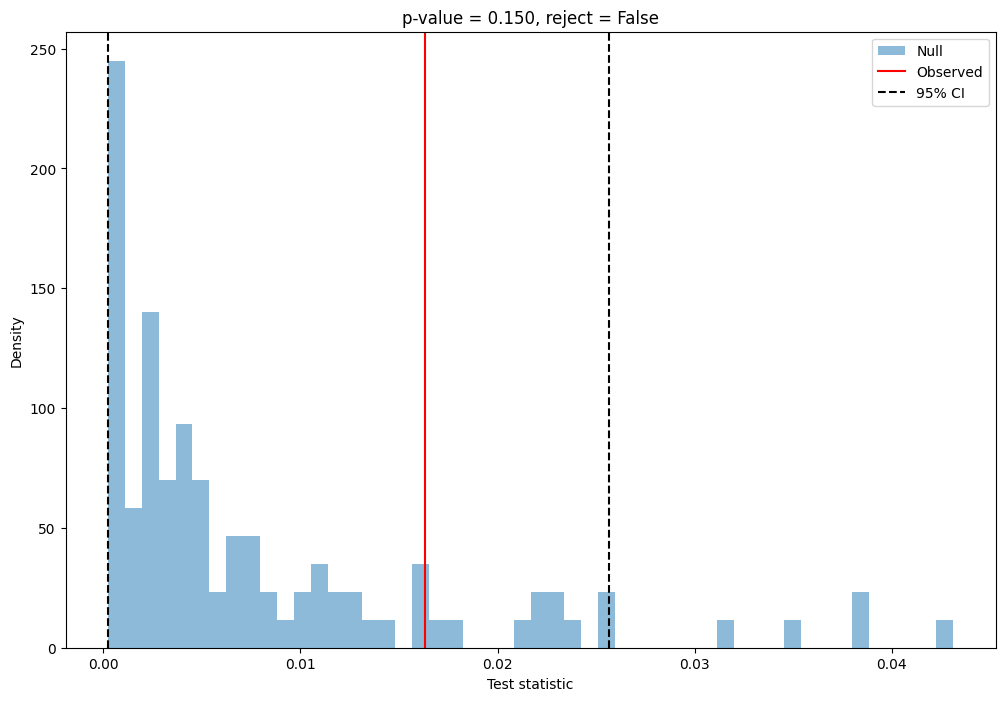

In [11]:
conf_alpha = 0.05
p_value = lc2st.p_value(post_samples_star, xs_star)
reject = lc2st.reject_test(post_samples_star, xs_star, alpha=conf_alpha)

# plot 95% confidence interval
quantiles = np.quantile(T_null, [0, 1 - conf_alpha])

fig, ax = plt.subplots(figsize=(12,8))

ax.hist(T_null, bins=50, density=True, alpha=0.5, label="Null")

ax.axvline(T_data, color="red", label="Observed")
ax.axvline(quantiles[0], color="black", linestyle="--", label="95% CI")
ax.axvline(quantiles[1], color="black", linestyle="--")

ax.set(xlabel="Test statistic", ylabel="Density", title=f"p-value = {p_value:.3f}, reject = {reject}")
ax.legend(loc="upper right")

### qualitative test

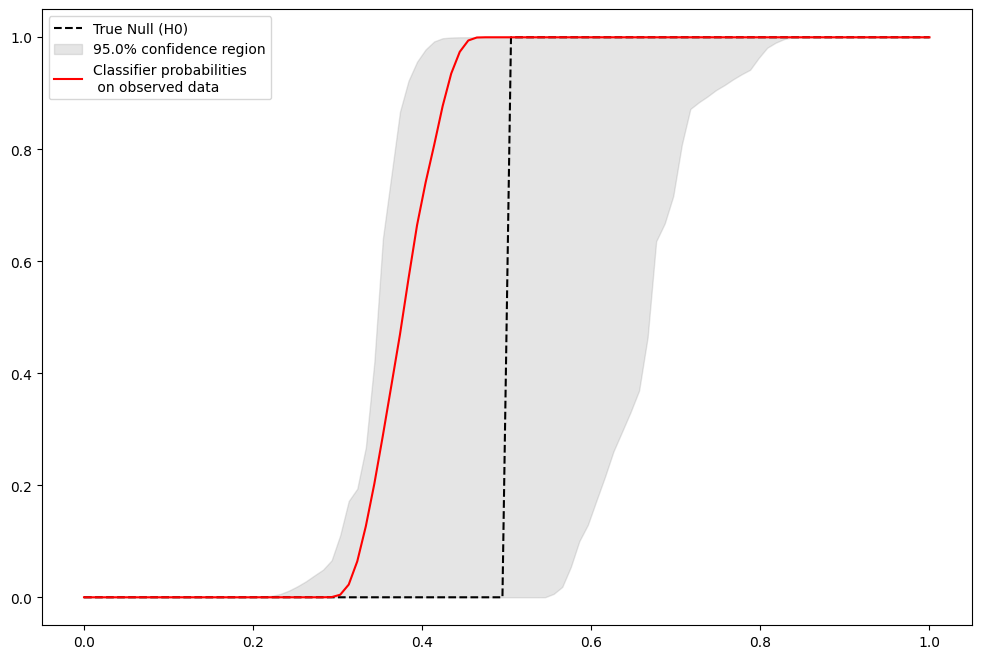

In [12]:
from sbi.analysis.plot import pp_plot_lc2st

fig, ax = plt.subplots(figsize=(12,8))

pp_plot_lc2st(
    probs=[probs_data],
    probs_null=probs_null,
    conf_alpha=conf_alpha,
    labels=["Classifier probabilities \n on observed data"],
    colors=["red"],
    ax=ax,
)

ax.legend()